<center>
<h1>Лабораторна робота №3</h1>
<h2>Візуалізація даних</h2>
</center>

### Завдання 1
Для роботи обрано багатовимірний датасет Hepatitis з репозиторію UCI. Він містить числівні та категоріальні ознаки, а також пропуски, що відповідає вимогам.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/hepatitis/hepatitis.data"

columns = [
    "Class", "Age", "Sex", "Steroid", "Antivirals", "Fatigue", "Malaise", 
    "Anorexia", "Liver_Big", "Liver_Firm", "Spleen_Palpable", "Spiders", 
    "Ascites", "Varices", "Bilirubin", "Alk_Phosphate", "SGOT", "Albumin", 
    "Protime", "Histology"
]
df = pd.read_csv(url, names=columns, na_values="?")
print(f"Знайдено пропусків:\n{df.isnull().sum()}")
df.head()

Знайдено пропусків:
Class               0
Age                 0
Sex                 0
Steroid             1
Antivirals          0
Fatigue             1
Malaise             1
Anorexia            1
Liver_Big          10
Liver_Firm         11
Spleen_Palpable     5
Spiders             5
Ascites             5
Varices             5
Bilirubin           6
Alk_Phosphate      29
SGOT                4
Albumin            16
Protime            67
Histology           0
dtype: int64


,Class,Age,Sex,Steroid,Antivirals,Fatigue,Malaise,Anorexia,Liver_Big,Liver_Firm,Spleen_Palpable,Spiders,Ascites,Varices,Bilirubin,Alk_Phosphate,SGOT,Albumin,Protime,Histology
0,2,30,2,1.0,2,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,85.0,18.0,4.0,NaN,1
1,2,50,1,1.0,2,1.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,0.9,135.0,42.0,3.5,NaN,1
2,2,78,1,2.0,2,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.7,96.0,32.0,4.0,NaN,1
3,2,31,1,NaN,1,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.7,46.0,52.0,4.0,80.0,1
4,2,34,1,2.0,2,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,NaN,200.0,4.0,NaN,1


### Завдання 2
Здійснити Data Cleaning.

In [4]:
cols_to_fix = ["Bilirubin", "Alk_Phosphate", "SGOT", "Albumin", "Protime"]
for col in cols_to_fix:
    df[col] = df[col].fillna(df[col].median())

df = df.apply(lambda x: x.fillna(x.value_counts().index[0]))
print("Після очищення пропусків залишилось:", df.isnull().sum().sum())

Після очищення пропусків залишилось: 0


### Завдання 3
Побудовано графік залежності Альбуміну від Віку для різних статей.

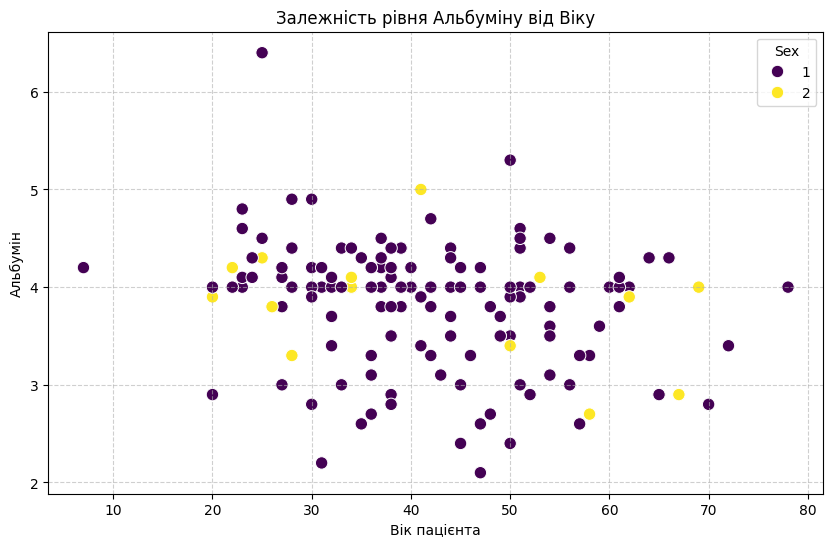

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Age", y="Albumin", hue="Sex", palette="viridis", s=80)
plt.title("Залежність рівня Альбуміну від Віку")
plt.xlabel("Вік пацієнта")
plt.ylabel("Альбумін")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Завдання 4
Гістограма з власними діапазонами. Атрибут Вік розділено на 5 заданих діапазонів для аналізу вікової структури пацієнтів.

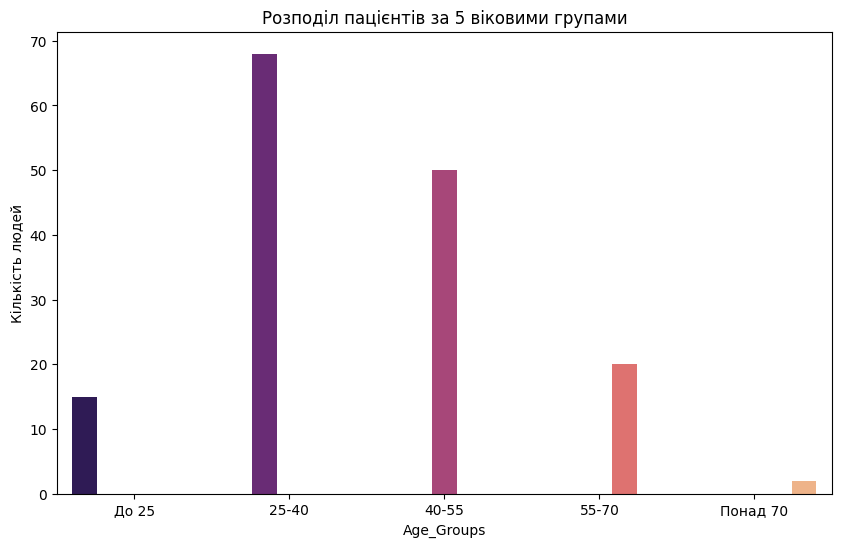

In [7]:
bins = [0, 25, 40, 55, 70, 90]
labels = ['До 25', '25-40', '40-55', '55-70', 'Понад 70']
df['Age_Groups'] = pd.cut(df['Age'], bins=bins, labels=labels)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Age_Groups', palette='magma', hue='Age_Groups', legend=False)
plt.title("Розподіл пацієнтів за 5 віковими групами")
plt.ylabel("Кількість людей")
plt.show()

### Завдання 5
Розподіл показників крові за класом результату.

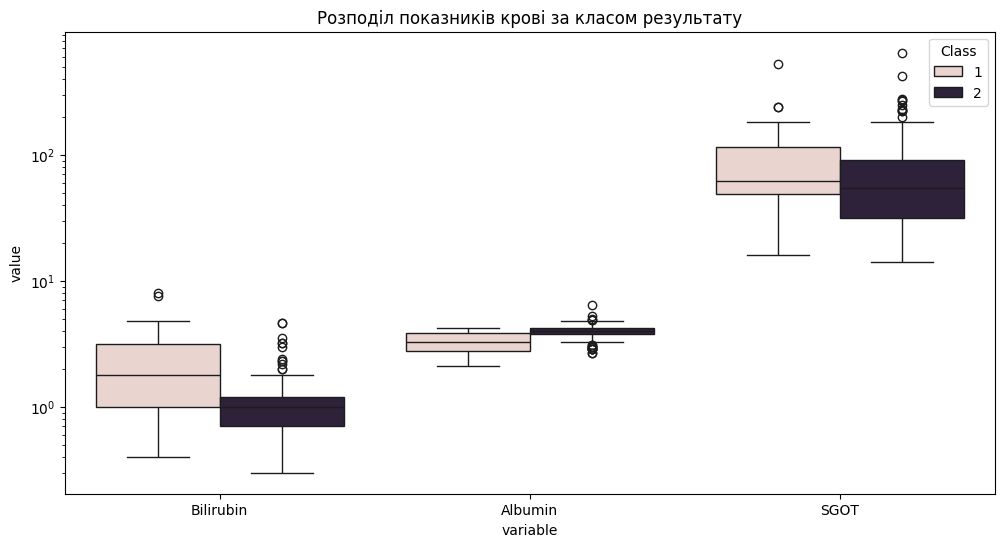

In [8]:
melted_df = df.melt(id_vars='Class', value_vars=['Bilirubin', 'Albumin', 'SGOT'])
plt.figure(figsize=(12, 6))
sns.boxplot(data=melted_df, x='variable', y='value', hue='Class')
plt.title("Розподіл показників крові за класом результату")
plt.yscale('log') 
plt.show()

Теплова карта кореляції. 

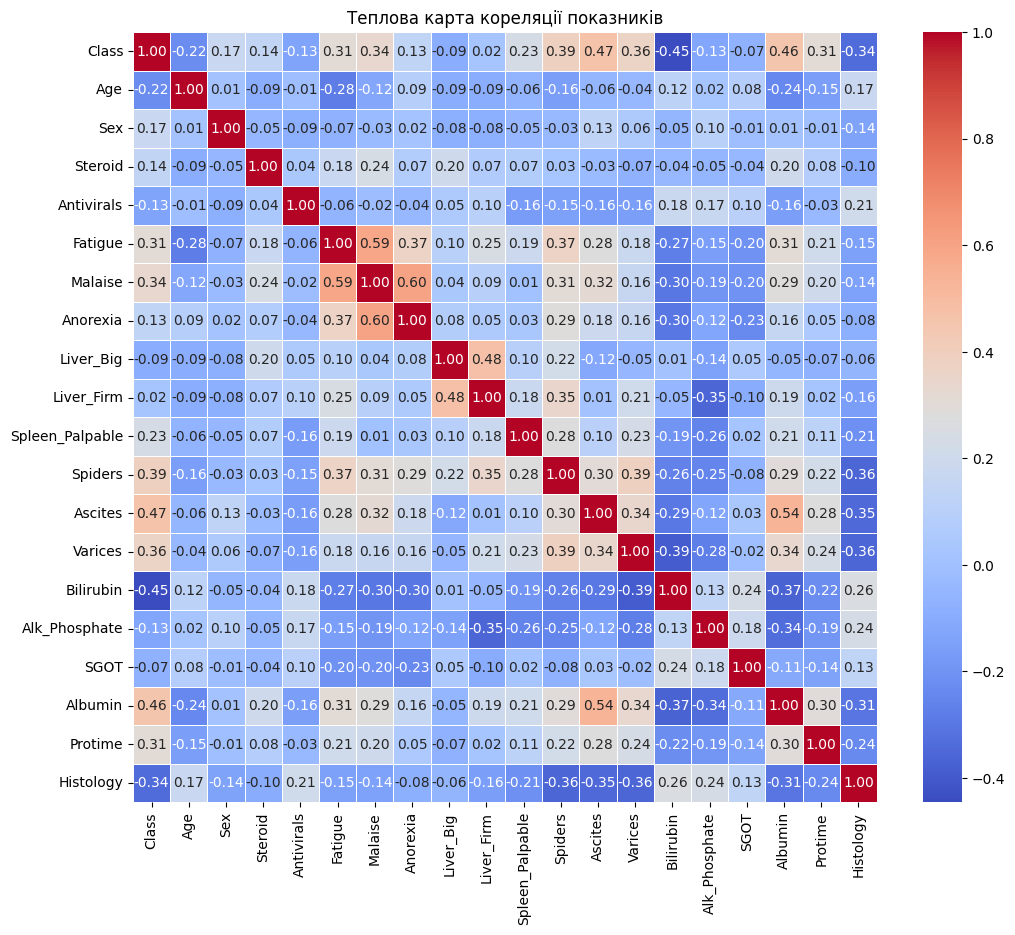

In [9]:
plt.figure(figsize=(12, 10))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Теплова карта кореляції показників")
plt.show()

Розподіл рівня Альбуміну за класом результату.

C:\Users\Andrii.Pinchuk\AppData\Local\Temp\ipykernel_48364\1396613684.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Class', y='Albumin', palette='Pastel1', inner="quart")


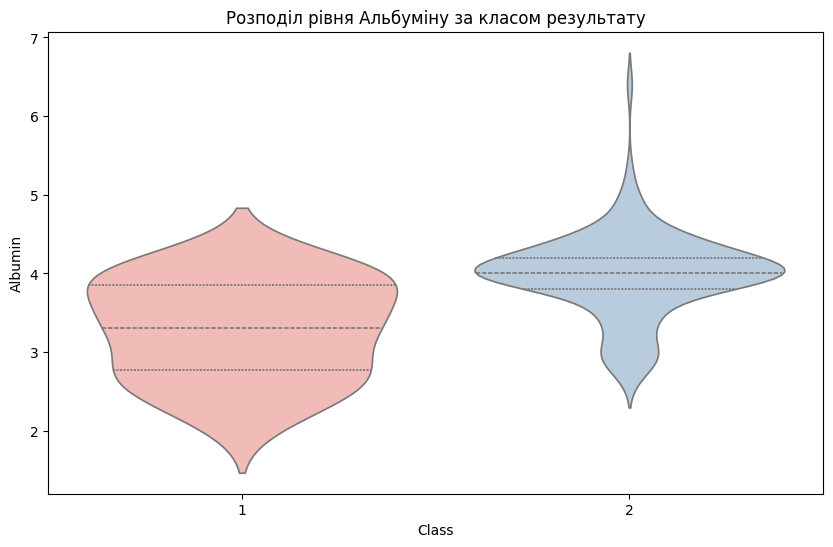

In [11]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Class', y='Albumin', palette='Pastel1', inner="quart")
plt.title("Розподіл рівня Альбуміну за класом результату")
plt.show()

### Завдання 6
Співвідношення результатів лікування. Кругова діаграма відображає баланс класів у датасеті. Пацієнти, що одужали (79.4%), що померли (20.6%).

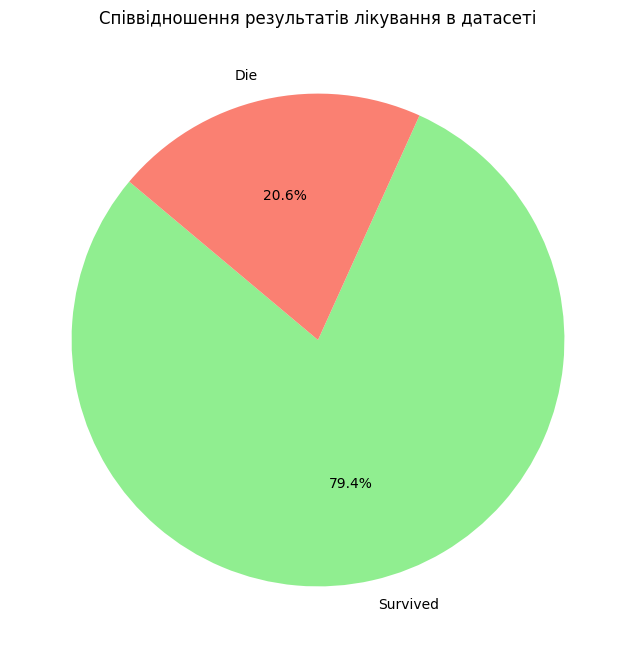

In [13]:
plt.figure(figsize=(8, 8))
class_counts = df['Class'].value_counts()
plt.pie(class_counts, labels=['Survived', 'Die'], autopct='%1.1f%%', colors=['lightgreen', 'salmon'], startangle=140)
plt.title("Співвідношення результатів лікування в датасеті")
plt.show()